In [1]:
# ============================================
# CELL 1: Setup
# ============================================
!pip install -q faiss-cpu sentence-transformers matplotlib numpy

import faiss
import numpy as np
import time
from sentence_transformers import SentenceTransformer

print("FAISS version:", faiss.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 53.6 MB/s eta 0:00:00
FAISS version: 1.15.1


In [2]:
# ============================================
# CELL 2: Generate a realistic-ish embedding dataset
# ============================================
model = SentenceTransformer("all-MiniLM-L6-v2")
d = model.get_embedding_dimension()
print("Embedding dimension:", d)

# Simulate a larger corpus by generating synthetic but semantically
# varied sentences, then also adding random noise vectors to pad size
np.random.seed(42)

base_sentences = [
    "The stock market rallied today amid strong earnings.",
    "Scientists discovered a new exoplanet orbiting a distant star.",
    "The chef prepared a delicious pasta dish for dinner.",
    "Machine learning models are transforming healthcare diagnostics.",
    "The soccer team won the championship after a thrilling match.",
    "Climate change is accelerating glacier melt in the Arctic.",
    "The new smartphone features a faster processor and better camera.",
    "Historians debate the causes of the fall of the Roman Empire.",
    "Yoga and meditation can reduce stress and improve focus.",
    "The company announced layoffs amid economic uncertainty.",
]
real_embeddings = model.encode(base_sentences).astype("float32")

# Pad with random vectors to simulate a larger dataset (50,000 vectors)
N = 50_000
random_embeddings = np.random.normal(0, 0.3, (N - len(base_sentences), d)).astype("float32")
all_embeddings = np.vstack([real_embeddings, random_embeddings])

# Normalize (so we can use dot product == cosine similarity)
faiss.normalize_L2(all_embeddings)
print("Total dataset shape:", all_embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384
Total dataset shape: (50000, 384)


In [3]:
# ============================================
# CELL 3: Build a FLAT (brute-force / exact) index — our ground truth
# ============================================
index_flat = faiss.IndexFlatIP(d)  # IP = Inner Product = cosine sim (since normalized)
index_flat.add(all_embeddings)
print("Flat index size:", index_flat.ntotal)

query = model.encode(["Tell me about advances in medical technology"]).astype("float32")
faiss.normalize_L2(query)

start = time.time()
D_flat, I_flat = index_flat.search(query, k=5)
flat_time = time.time() - start

print(f"\nFlat search time: {flat_time*1000:.3f} ms")
for score, idx in zip(D_flat[0], I_flat[0]):
    text = base_sentences[idx] if idx < len(base_sentences) else "[random padding vector]"
    print(f"  score={score:.4f} | {text}")

Flat index size: 50000

Flat search time: 68.151 ms
  score=0.3427 | The new smartphone features a faster processor and better camera.
  score=0.3031 | Machine learning models are transforming healthcare diagnostics.
  score=0.2156 | [random padding vector]
  score=0.2015 | [random padding vector]
  score=0.1938 | [random padding vector]


In [4]:
# ============================================
# CELL 4: Build an IVF index — cluster-based ANN
# ============================================
nlist = 100  # number of clusters
quantizer = faiss.IndexFlatIP(d)
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)

# IVF requires a training step (k-means clustering)
index_ivf.train(all_embeddings)
index_ivf.add(all_embeddings)

# nprobe = number of clusters to search at query time (THE key tuning knob)
index_ivf.nprobe = 8

start = time.time()
D_ivf, I_ivf = index_ivf.search(query, k=5)
ivf_time = time.time() - start

print(f"IVF search time: {ivf_time*1000:.3f} ms  (nprobe={index_ivf.nprobe})")
for score, idx in zip(D_ivf[0], I_ivf[0]):
    text = base_sentences[idx] if idx < len(base_sentences) else "[random padding vector]"
    print(f"  score={score:.4f} | {text}")

IVF search time: 6.068 ms  (nprobe=8)
  score=0.3031 | Machine learning models are transforming healthcare diagnostics.
  score=0.1931 | [random padding vector]
  score=0.1853 | [random padding vector]
  score=0.1826 | [random padding vector]
  score=0.1826 | [random padding vector]


In [5]:
# ============================================
# CELL 5: Build an HNSW index — graph-based ANN
# ============================================
M = 32  # connections per node
index_hnsw = faiss.IndexHNSWFlat(d, M, faiss.METRIC_INNER_PRODUCT)
index_hnsw.hnsw.efConstruction = 40
index_hnsw.add(all_embeddings)

index_hnsw.hnsw.efSearch = 16  # THE key query-time tuning knob

start = time.time()
D_hnsw, I_hnsw = index_hnsw.search(query, k=5)
hnsw_time = time.time() - start

print(f"HNSW search time: {hnsw_time*1000:.3f} ms  (efSearch={index_hnsw.hnsw.efSearch})")
for score, idx in zip(D_hnsw[0], I_hnsw[0]):
    text = base_sentences[idx] if idx < len(base_sentences) else "[random padding vector]"
    print(f"  score={score:.4f} | {text}")

HNSW search time: 1.052 ms  (efSearch=16)
  score=0.1704 | [random padding vector]
  score=0.1591 | [random padding vector]
  score=0.1519 | [random padding vector]
  score=0.1483 | [random padding vector]
  score=0.1477 | [random padding vector]


In [6]:
# ============================================
# CELL 6: Measure Recall@K of ANN indexes vs brute-force ground truth
# ============================================
def compute_recall_at_k(index, queries, ground_truth_ids, k=5):
    D, I = index.search(queries, k)
    recalls = []
    for i in range(len(queries)):
        true_set = set(ground_truth_ids[i])
        found_set = set(I[i])
        recall = len(true_set & found_set) / len(true_set)
        recalls.append(recall)
    return np.mean(recalls)

# Generate multiple random queries for a robust recall measurement
test_queries = model.encode([
    "Tell me about advances in medical technology",
    "What happened in the financial markets recently?",
    "Describe an exciting sports event",
    "Explain a scientific discovery",
    "How can I be healthier and less stressed?",
]).astype("float32")
faiss.normalize_L2(test_queries)

k = 10
_, ground_truth_ids = index_flat.search(test_queries, k)

ivf_recall = compute_recall_at_k(index_ivf, test_queries, ground_truth_ids, k)
hnsw_recall = compute_recall_at_k(index_hnsw, test_queries, ground_truth_ids, k)

print(f"IVF  Recall@{k}:  {ivf_recall:.2%}")
print(f"HNSW Recall@{k}: {hnsw_recall:.2%}")

IVF  Recall@10:  20.00%
HNSW Recall@10: 12.00%


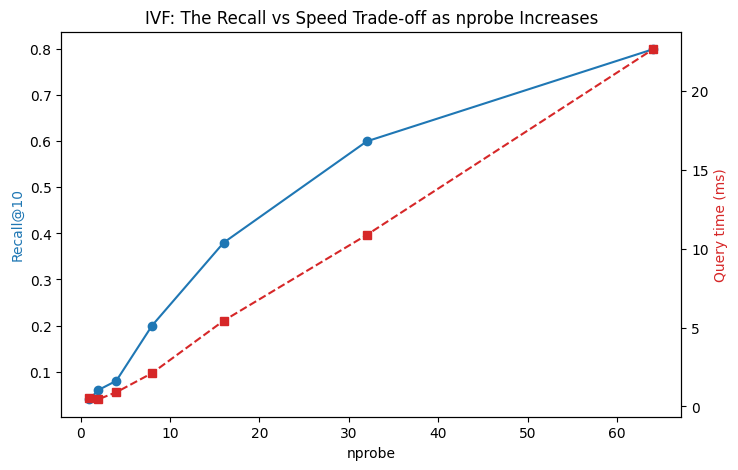

Notice: recall climbs and plateaus, while query time keeps climbing.
This exact chart is what you'd generate in production to pick nprobe.


In [7]:
# ============================================
# CELL 7: Visualize speed vs recall trade-off (the core lesson of this topic)
# ============================================
import matplotlib.pyplot as plt

nprobe_values = [1, 2, 4, 8, 16, 32, 64]
results = []

for nprobe in nprobe_values:
    index_ivf.nprobe = nprobe
    start = time.time()
    for _ in range(20):  # repeat for stable timing
        index_ivf.search(test_queries, k)
    elapsed = (time.time() - start) / 20
    recall = compute_recall_at_k(index_ivf, test_queries, ground_truth_ids, k)
    results.append((nprobe, elapsed * 1000, recall))

nprobes, times, recalls = zip(*results)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(nprobes, recalls, 'o-', color='tab:blue', label='Recall@10')
ax1.set_xlabel('nprobe')
ax1.set_ylabel('Recall@10', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(nprobes, times, 's--', color='tab:red', label='Query time (ms)')
ax2.set_ylabel('Query time (ms)', color='tab:red')
plt.title('IVF: The Recall vs Speed Trade-off as nprobe Increases')
plt.show()

print("Notice: recall climbs and plateaus, while query time keeps climbing.")
print("This exact chart is what you'd generate in production to pick nprobe.")

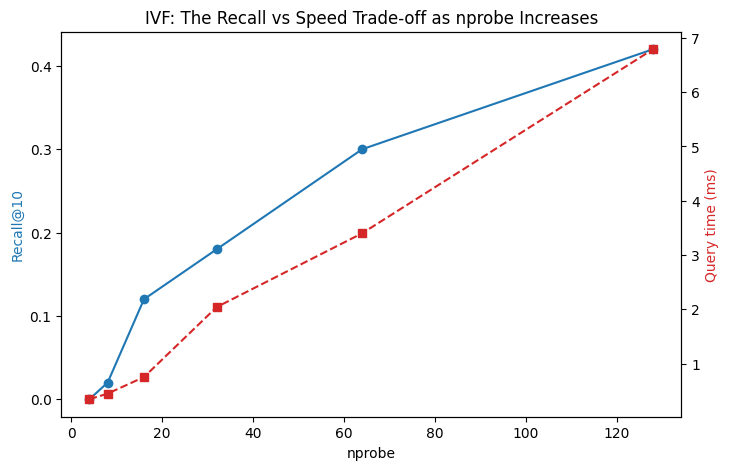

Notice: recall climbs and plateaus, while query time keeps climbing.
This exact chart is what you'd generate in production to pick nprobe.


In [8]:
# ============================================
# CELL 7: Visualize speed vs recall trade-off (the core lesson of this topic)
# ============================================
import matplotlib.pyplot as plt

nprobe_values = [4, 8, 16, 32, 64, 128]
results = []

for ef_search in nprobe_values:
    index_hnsw.hnsw.efSearch = ef_search
    start = time.time()
    for _ in range(20):  # repeat for stable timing
        index_hnsw.search(test_queries, k)
    elapsed = (time.time() - start) / 20
    recall = compute_recall_at_k(index_hnsw, test_queries, ground_truth_ids, k)
    results.append((ef_search, elapsed * 1000, recall))

efsearches, times, recalls = zip(*results)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(efsearches, recalls, 'o-', color='tab:blue', label='Recall@10')
ax1.set_xlabel('nprobe')
ax1.set_ylabel('Recall@10', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(efsearches, times, 's--', color='tab:red', label='Query time (ms)')
ax2.set_ylabel('Query time (ms)', color='tab:red')
plt.title('IVF: The Recall vs Speed Trade-off as nprobe Increases')
plt.show()

print("Notice: recall climbs and plateaus, while query time keeps climbing.")
print("This exact chart is what you'd generate in production to pick nprobe.")

# **Product Quantization**

In [9]:
# ============================================
# Exercise: IVF-PQ vs plain IVF — Recall & Memory Trade-off
# (Assumes Cells 1-6 from the previous notebook already ran:
#  quantizer, d, nlist, all_embeddings, index_ivf, test_queries,
#  ground_truth_ids, k, compute_recall_at_k are already defined)
# ============================================

# --- Build IVF-PQ index ---
m = 8       # number of sub-vector splits (d must be divisible by m)
nbits = 8   # bits per sub-vector code (8 bits = 256 centroids per sub-space)

quantizer_pq = faiss.IndexFlatIP(d)  # fresh quantizer for this index
index_ivfpq = faiss.IndexIVFPQ(quantizer_pq, d, nlist, m, nbits, faiss.METRIC_INNER_PRODUCT)

index_ivfpq.train(all_embeddings)
index_ivfpq.add(all_embeddings)

# Match nprobe to plain IVF for a fair comparison
index_ivfpq.nprobe = 8

# --- Recall comparison ---
ivfpq_recall = compute_recall_at_k(index_ivfpq, test_queries, ground_truth_ids, k)
ivf_recall = compute_recall_at_k(index_ivf, test_queries, ground_truth_ids, k)  # plain IVF, nprobe=8

print(f"Plain IVF   Recall@{k}: {ivf_recall:.2%}")
print(f"IVF-PQ      Recall@{k}: {ivfpq_recall:.2%}")
print(f"Recall drop from compression: {(ivf_recall - ivfpq_recall):.2%}\n")

# --- Memory footprint comparison ---
# sa_code_size() = bytes used to store ONE encoded vector by this index
ivf_code_size = index_ivf.sa_code_size()
ivfpq_code_size = index_ivfpq.sa_code_size()

ivf_total_mb = (ivf_code_size * index_ivf.ntotal) / (1024 ** 2)
ivfpq_total_mb = (ivfpq_code_size * index_ivfpq.ntotal) / (1024 ** 2)

print(f"Plain IVF  -> bytes/vector: {ivf_code_size}, total size: {ivf_total_mb:.2f} MB")
print(f"IVF-PQ     -> bytes/vector: {ivfpq_code_size}, total size: {ivfpq_total_mb:.2f} MB")
print(f"Memory compression ratio: {ivf_total_mb / ivfpq_total_mb:.1f}x smaller")

# --- Query time comparison (bonus, since we're already here) ---
start = time.time()
for _ in range(20):
    index_ivf.search(test_queries, k)
ivf_time = (time.time() - start) / 20 * 1000

start = time.time()
for _ in range(20):
    index_ivfpq.search(test_queries, k)
ivfpq_time = (time.time() - start) / 20 * 1000

print(f"\nPlain IVF  query time: {ivf_time:.3f} ms")
print(f"IVF-PQ     query time: {ivfpq_time:.3f} ms")

print(f"""
SUMMARY:
IVF-PQ compresses each vector from {ivf_code_size} bytes down to {ivfpq_code_size} bytes
({ivf_total_mb / ivfpq_total_mb:.1f}x smaller), at a recall@{k} cost of
{(ivf_recall - ivfpq_recall):.2%} — this is the memory/accuracy trade-off PQ makes.
""")

Plain IVF   Recall@10: 80.00%
IVF-PQ      Recall@10: 0.00%
Recall drop from compression: 80.00%

Plain IVF  -> bytes/vector: 1537, total size: 73.29 MB
IVF-PQ     -> bytes/vector: 9, total size: 0.43 MB
Memory compression ratio: 170.8x smaller

Plain IVF  query time: 38.658 ms
IVF-PQ     query time: 1.058 ms

SUMMARY:
IVF-PQ compresses each vector from 1537 bytes down to 9 bytes
(170.8x smaller), at a recall@10 cost of 
80.00% — this is the memory/accuracy trade-off PQ makes.

